## Load and Prepare Data

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
from sklearn.model_selection import train_test_split

In [9]:
pip install xgboost


You should consider upgrading via the 'C:\python new\python.exe -m pip install --upgrade pip' command.


In [10]:
from xgboost import XGBClassifier

In [11]:
email_df = pd.read_csv("email_table.csv")
open_df = pd.read_csv("email_opened_table.csv")
click_df = pd.read_csv("link_clicked_table.csv")

In [5]:
email_df.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases
0,85120,short_email,personalized,2,Sunday,US,5
1,966622,long_email,personalized,12,Sunday,UK,2
2,777221,long_email,personalized,11,Wednesday,US,2
3,493711,short_email,generic,6,Monday,UK,1
4,106887,long_email,generic,14,Monday,US,6


In [12]:
open_df.head()

,email_id
0,284534
1,609056
2,220820
3,905936
4,164034


In [13]:
click_df.head()

,email_id
0,609056
1,870980
2,935124
3,158501
4,177561


In [15]:
email_df["opened"] = email_df["email_id"].isin(open_df["email_id"]).astype(int)
email_df["clicked"] = email_df["email_id"].isin(click_df["email_id"]).astype(int)

In [16]:
email_df.head()


,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases,opened,clicked
0,85120,short_email,personalized,2,Sunday,US,5,0,0
1,966622,long_email,personalized,12,Sunday,UK,2,1,1
2,777221,long_email,personalized,11,Wednesday,US,2,0,0
3,493711,short_email,generic,6,Monday,UK,1,0,0
4,106887,long_email,generic,14,Monday,US,6,0,0


## Open Rate and Click-Through Rate

In [20]:
open_rate = email_df["opened"].mean()
ctr = email_df["clicked"].mean()

In [38]:
print(f" Open Rate: {open_rate:.2%}")

 Open Rate: 10.35%


In [39]:
print(f" ctr : {ctr : .2%}")

 ctr :  2.12%


In [26]:
email_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   email_id             100000 non-null  int64 
 1   email_text           100000 non-null  object
 2   email_version        100000 non-null  object
 3   hour                 100000 non-null  int64 
 4   weekday              100000 non-null  object
 5   user_country         100000 non-null  object
 6   user_past_purchases  100000 non-null  int64 
 7   opened               100000 non-null  int64 
 8   clicked              100000 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 6.9+ MB


In [30]:
df = email_df.copy()

## Train XGBoost Classifier

In [32]:
df = pd.get_dummies(df, columns=["email_text", "email_version", "weekday", "user_country"], drop_first=True)

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x = df.drop(columns=['email_id', 'opened', 'clicked'])
y = df['clicked']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42)

In [48]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(x_train, y_train)

C:\python new\lib\site-packages\xgboost\training.py:183: UserWarning: [08:21:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred = model.predict(x_test)

##  Evaluation: Classification Report + AUC + Confusion Matrix

In [52]:
print("\n Classification Report:")
print(classification_report(y_test, y_pred))



 Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     24470
           1       0.00      0.00      0.00       530

    accuracy                           0.98     25000
   macro avg       0.49      0.50      0.49     25000
weighted avg       0.96      0.98      0.97     25000



In [54]:
y_prob = model.predict_proba(x_test)[:,1]
print(f" ROC Score : {roc_auc_score(y_test, y_prob):.3f}")


 ROC Score : 0.720


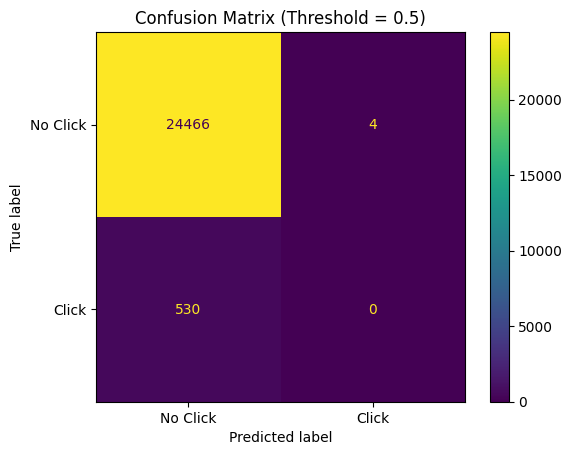

In [56]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Click", "Click"])
disp.plot()
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

## Estimate CTR Uplift from Model-Based Targeting

In [60]:
test_df = x_test.copy()

In [61]:
test_df.head()

,hour,user_past_purchases,email_text_short_email,email_version_personalized,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,user_country_FR,user_country_UK,user_country_US
71980,8,0,False,False,False,False,False,False,False,True,False,False,True
63090,7,2,False,True,True,False,False,False,False,False,False,False,True
73405,15,10,True,True,False,False,False,True,False,False,False,True,False
92218,19,5,True,False,False,False,False,False,False,True,False,False,True
50653,3,0,False,False,False,False,False,False,True,False,False,False,False


In [62]:
test_df['actual_clicked'] = y_test
test_df['pred_prob'] = y_prob

In [63]:
test_df.head()

,hour,user_past_purchases,email_text_short_email,email_version_personalized,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,user_country_FR,user_country_UK,user_country_US,actual_clicked,pred_prob
71980,8,0,False,False,False,False,False,False,False,True,False,False,True,0,0.000156
63090,7,2,False,True,True,False,False,False,False,False,False,False,True,0,0.011705
73405,15,10,True,True,False,False,False,True,False,False,False,True,False,0,0.054280
92218,19,5,True,False,False,False,False,False,False,True,False,False,True,0,0.004175
50653,3,0,False,False,False,False,False,False,True,False,False,False,False,0,0.000036


### Suppose we only send Email to 30% most likely to click

In [66]:
threshold = test_df['pred_prob'].quantile(0.7)
high_prob_df = test_df[test_df['pred_prob'] >= threshold]
imp_ctr = high_prob_df['actual_clicked'].mean()

In [68]:
high_prob_df.head()

,hour,user_past_purchases,email_text_short_email,email_version_personalized,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,user_country_FR,user_country_UK,user_country_US,actual_clicked,pred_prob
73405,15,10,True,True,False,False,False,True,False,False,False,True,False,0,0.054280
17681,4,3,True,True,False,False,False,False,False,True,False,False,True,0,0.025087
63828,5,6,True,True,False,False,False,False,True,False,False,False,True,0,0.027879
93905,1,8,False,True,False,False,False,False,True,False,False,False,True,0,0.076507
20357,11,7,False,True,False,False,True,False,False,False,False,False,True,0,0.029142


In [72]:
print(f"\n Estimated CTR if we target top 30%: {imp_ctr:.2%}")
print(f" CTR Improvement: {(imp_ctr - ctr):.2%}")


 Estimated CTR if we target top 30%: 4.24%
 CTR Improvement: 2.12%


## Segment Analysis (CTR by Email Content & Timing)

In [73]:
# Segment Analysis
seg = email_df.groupby(['email_text', 'email_version', 'weekday'])['clicked'].mean().reset_index()
print("\n seg Click Through Rates:")
print(seg.sort_values('clicked', ascending=False))


 seg Click Through Rates:
     email_text email_version    weekday   clicked
27  short_email  personalized  Wednesday  0.039443
26  short_email  personalized    Tuesday  0.035127
22  short_email  personalized     Monday  0.032945
13   long_email  personalized  Wednesday  0.032267
25  short_email  personalized   Thursday  0.031998
24  short_email  personalized     Sunday  0.029305
23  short_email  personalized   Saturday  0.028395
11   long_email  personalized   Thursday  0.026518
8    long_email  personalized     Monday  0.026467
12   long_email  personalized    Tuesday  0.025241
20  short_email       generic  Wednesday  0.021832
21  short_email  personalized     Friday  0.021381
18  short_email       generic   Thursday  0.021217
19  short_email       generic    Tuesday  0.020179
7    long_email  personalized     Friday  0.019484
5    long_email       generic    Tuesday  0.018815
15  short_email       generic     Monday  0.018207
4    long_email       generic   Thursday  0.018086
9   

In [78]:
# Heatmap for Above representation
email_df['clicked'] = email_df['email_id'].isin(click_df['email_id']).astype(int)

# Create pivot table for heatmap
pivot_table = seg.pivot_table(
    index='weekday',                         
    columns=['email_text', 'email_version'], 
    values='clicked'                         
)

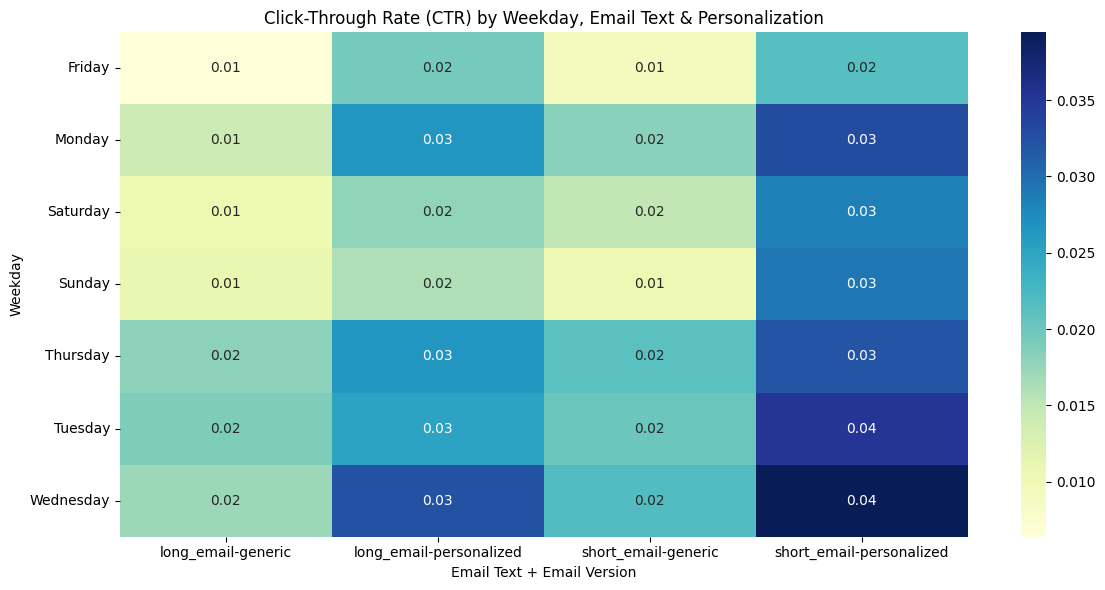

In [79]:
# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Click-Through Rate (CTR) by Weekday, Email Text & Personalization")
plt.ylabel("Weekday")
plt.xlabel("Email Text + Email Version")
plt.tight_layout()
plt.show()